In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn import preprocessing
import sys
import matplotlib.pyplot as plt
import timeit
import math

import time
# from time import time

import seaborn as sns
sns.set(style="darkgrid")

import numpy.random as nr

import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import SGDClassifier, Perceptron
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, train_test_split

from sklearn.ensemble import RandomForestClassifier as RF
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPRegressor
#from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

%matplotlib inline
#%matplotlib notebook

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# pca = PCA(random_state= '42')
# pca.fit(num_df)
# plt.plot(pca.explained_variance_ratio_)
nr.seed = 42

https://github.com/adomakor412/MachineLearning_DataMining/blob/master/HW/HW2/hw2_problem4.ipynb

In [3]:
#pd.read_csv?

In [4]:
data = pd.read_csv("dataDropped_from_162by127_to_157rowsby84columns.csv", sep=";")
#data#.head()

In [5]:
#data.loc[1]
#data.iloc[1]
#data.loc?

In [6]:
data.columns

Index(['Unnamed: 0', '1', '2', '3', '4', '5', '6', '7', '8', '15', '16', '22',
       '23', '25', '26', '28', '29', '30', '32', '33', '34', '35', '44', '45',
       '46', '47', '48', '49', '55', '60', '61', '62', '65', '66', '67', '68',
       '69', '70', '71', '72', '75', '76', '79', '82', '83', '85', '86', '87',
       '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '100',
       '101', '102', '103', '104', '105', '106', '107', '108', '110', '111',
       '112', '113', '114', '115', '117', '118', '119', '120', '121', '122',
       '123', '124', '125', '126', '127'],
      dtype='object')

In [7]:
dfexp = data[data.columns[1:]]
dfexp 

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
0,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000
1,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000
2,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000
3,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000
4,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000
153,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
154,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000
155,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,31.4,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000


In [8]:
dfexp.index

RangeIndex(start=0, stop=157, step=1)

In [9]:
dfexp.index = range(4, 161)

In [10]:
dfexp

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,31.4,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000


In [11]:
df_Target = dfexp[dfexp['97']/2 >= dfexp['124']]
df_Target

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
11,7.0,45.0,3.0,147.0,1.0,585.0,75.0,800.0,277821.0,420.5,...,44.5,40.5,42.1,56.88,468.65,525.53,284.40,1848.0,284.40,3118.0
12,8.0,46.0,44.0,46.0,1.0,1450.0,150.0,1450.0,830000.0,550.1,...,43.3,39.3,40.9,218.12,2002.57,2220.69,1090.62,2036.0,1090.62,3103.0
30,26.0,248.0,14.0,61.0,1.0,400.0,80.0,500.0,104000.0,250.0,...,29.0,25.0,26.6,32.21,146.18,178.39,161.04,1108.0,161.04,2074.0
31,27.0,249.0,14.0,62.0,1.0,400.0,80.0,500.0,104000.0,250.0,...,29.0,25.0,26.6,32.21,146.18,178.39,161.04,1108.0,161.04,2167.0
83,82.0,485.0,19.0,39.0,1.0,300.0,50.0,350.0,41250.0,127.7,...,23.8,19.8,21.4,11.51,48.41,59.93,57.56,1041.0,57.56,1704.0
84,80.0,490.0,20.0,117.0,1.0,1500.0,100.0,900.0,362500.0,291.7,...,24.2,20.2,21.8,64.01,1020.61,1084.63,320.07,3389.0,320.07,2500.0
96,94.0,504.0,22.0,65.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,25.0,21.0,22.6,89.07,453.60,542.66,445.33,1219.0,445.33,1518.0
97,95.0,505.0,22.0,66.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,25.0,21.0,22.6,89.07,453.60,542.66,445.33,1219.0,445.33,1545.0
100,98.0,508.0,22.0,69.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,50.0,46.0,47.6,129.26,680.39,809.65,646.29,1253.0,646.29,1827.0
101,99.0,509.0,22.0,70.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,50.0,46.0,47.6,129.26,680.39,809.65,646.29,1253.0,646.29,1917.0


In [12]:
dfexp.index

RangeIndex(start=4, stop=161, step=1)

In [13]:
df_Target.index

Index([ 11,  12,  30,  31,  83,  84,  96,  97, 100, 101, 102, 128, 129, 130,
       131, 134, 135, 147, 148, 149],
      dtype='int64')

In [14]:
df_Target.index.to_list

<bound method IndexOpsMixin.tolist of Index([ 11,  12,  30,  31,  83,  84,  96,  97, 100, 101, 102, 128, 129, 130,
       131, 134, 135, 147, 148, 149],
      dtype='int64')>

In [15]:
listTargetIndex = list(df_Target.index)
listTargetIndex

[11,
 12,
 30,
 31,
 83,
 84,
 96,
 97,
 100,
 101,
 102,
 128,
 129,
 130,
 131,
 134,
 135,
 147,
 148,
 149]

In [16]:
dfexp['Target'] = 0

In [17]:
for i in listTargetIndex:
    dfexp['Target'].iloc[i] = 1
#Try using conditional indices]

In [18]:
dfexp.iloc[listTargetIndex]

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
15,11.0,64.0,4.0,29.0,1.0,240.0,240.0,950.0,228000.0,475.0,...,22.7,24.3,176.75,140.42,317.17,883.75,0.359,317.17,1165.0,1
16,12.0,65.0,4.0,30.0,1.0,240.0,240.0,1250.0,300000.0,625.0,...,21.8,23.4,231.28,187.23,418.51,1156.42,0.362,418.51,1129.0,1
34,30.0,264.0,15.0,18.0,0.0,304.8,304.8,609.6,185806.0,304.8,...,51.9,53.5,199.42,122.65,322.06,997.08,0.323,322.06,1206.0,1
35,33.0,359.0,17.0,75.0,1.0,250.0,250.0,350.0,87500.0,175.0,...,57.6,59.2,93.28,63.69,156.97,466.41,0.337,156.97,1454.0,1
87,85.0,493.0,21.0,137.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,13.0,14.6,38.13,139.42,177.55,190.64,0.931,177.55,1549.0,1
88,86.0,494.0,21.0,138.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,13.0,14.6,38.13,82.66,120.79,190.64,0.634,120.79,1924.0,1
100,98.0,508.0,22.0,69.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,46.0,47.6,129.26,680.39,809.65,646.29,1253.000,646.29,1827.0,1
101,99.0,509.0,22.0,70.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,46.0,47.6,129.26,680.39,809.65,646.29,1253.000,646.29,1917.0,1
104,102.0,512.0,24.0,20.0,1.0,700.0,120.0,600.0,159600.0,261.1,...,22.6,24.2,52.95,219.52,272.47,264.73,1029.000,264.73,1643.0,1
105,103.0,523.0,25.0,72.0,1.0,650.0,86.3,490.0,90550.0,168.0,...,36.1,37.7,39.60,57.65,97.25,198.02,0.491,97.25,1296.0,1


In [19]:
dfexp

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000,0
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000,0
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000,0
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000,0
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000,0
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867,0
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000,0
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000,0


In [20]:
dfexp[dfexp['Target']==1]

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
15,11.0,64.0,4.0,29.0,1.0,240.0,240.0,950.0,228000.0,475.0,...,22.7,24.3,176.75,140.42,317.17,883.75,0.359,317.17,1165.0,1
16,12.0,65.0,4.0,30.0,1.0,240.0,240.0,1250.0,300000.0,625.0,...,21.8,23.4,231.28,187.23,418.51,1156.42,0.362,418.51,1129.0,1
34,30.0,264.0,15.0,18.0,0.0,304.8,304.8,609.6,185806.0,304.8,...,51.9,53.5,199.42,122.65,322.06,997.08,0.323,322.06,1206.0,1
35,33.0,359.0,17.0,75.0,1.0,250.0,250.0,350.0,87500.0,175.0,...,57.6,59.2,93.28,63.69,156.97,466.41,0.337,156.97,1454.0,1
87,85.0,493.0,21.0,137.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,13.0,14.6,38.13,139.42,177.55,190.64,0.931,177.55,1549.0,1
88,86.0,494.0,21.0,138.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,13.0,14.6,38.13,82.66,120.79,190.64,0.634,120.79,1924.0,1
100,98.0,508.0,22.0,69.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,46.0,47.6,129.26,680.39,809.65,646.29,1253.000,646.29,1827.0,1
101,99.0,509.0,22.0,70.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,46.0,47.6,129.26,680.39,809.65,646.29,1253.000,646.29,1917.0,1
104,102.0,512.0,24.0,20.0,1.0,700.0,120.0,600.0,159600.0,261.1,...,22.6,24.2,52.95,219.52,272.47,264.73,1029.000,264.73,1643.0,1
105,103.0,523.0,25.0,72.0,1.0,650.0,86.3,490.0,90550.0,168.0,...,36.1,37.7,39.60,57.65,97.25,198.02,0.491,97.25,1296.0,1


In [21]:
scaler = StandardScaler()
standardized_features = scaler.fit_transform(dfexp)
standardized_features

array([[-1.72105355, -2.14908591, -1.9688346 , ..., -0.82491838,
        -0.56068325, -0.38208036],
       [-1.69898876, -2.13429062, -1.9688346 , ..., -0.74361089,
        -0.64454978, -0.38208036],
       [-1.67692397, -2.12935886, -1.9688346 , ..., -0.68477363,
        -0.80205522, -0.38208036],
       ...,
       [-1.03704509,  1.80125534, -0.52398724, ...,  0.98256227,
         0.25139022, -0.38208036],
       [-1.0149803 ,  1.8061871 , -0.52398724, ...,  0.57938694,
         0.4784435 , -0.38208036],
       [ 1.52247045,  2.06757048,  1.73358676, ...,  0.6372716 ,
        -3.1892137 , -0.38208036]])

In [22]:
df_standard = pd.DataFrame(standardized_features)
df_standard.index = dfexp.index
df_standard.columns = dfexp.columns

In [23]:
df_standard

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
4,-1.721054,-2.149086,-1.968835,-0.354802,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,-0.332096,-0.332096,-0.725716,-0.498787,-0.681524,-0.725763,-0.407708,-0.824918,-0.560683,-0.38208
5,-1.698989,-2.134291,-1.968835,-0.444502,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.012806,2.012806,-0.566462,-0.498787,-0.629092,-0.566421,-0.407836,-0.743611,-0.644550,-0.38208
6,-1.676924,-2.129359,-1.968835,-0.422077,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,1.677249,1.677249,-0.586341,-0.448635,-0.591150,-0.586388,-0.407751,-0.684774,-0.802055,-0.38208
7,-1.654859,-2.124427,-1.968835,-0.399652,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.216537,2.216537,-0.554820,-0.405199,-0.542187,-0.554779,-0.407712,-0.608846,-0.830693,-0.38208
8,-1.632794,-2.119495,-1.968835,-0.377227,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.036774,2.036774,-0.565034,-0.498787,-0.628658,-0.565015,-0.407837,-0.742938,-0.859330,-0.38208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,1.235628,1.786460,1.191769,-1.677882,0.486025,-0.841859,0.100142,-0.772621,-0.703170,-0.585147,...,-0.076434,-0.076434,-0.380409,-0.464959,-0.537887,-0.380455,-0.407872,-0.602177,0.050929,-0.38208
157,1.257693,1.796324,1.191769,-1.655457,0.486025,-0.841859,0.100142,-0.772621,-0.703170,-0.585147,...,0.023434,0.023434,-0.363275,-0.015704,-0.133461,-0.363300,-0.407435,0.024972,-3.189455,-0.38208
158,-1.037045,1.801255,-0.523987,-1.139680,0.486025,0.791178,-0.446278,1.484465,0.780059,0.641907,...,-0.759532,-0.759532,0.064405,0.521440,0.484055,0.064425,-0.407366,0.982562,0.251390,-0.38208
159,-1.014980,1.806187,-0.523987,-1.094830,0.486025,0.791178,-0.446278,1.484465,0.780059,0.641907,...,-0.735563,-0.735563,0.075058,0.224596,0.224061,0.075057,-0.407548,0.579387,0.478444,-0.38208


In [24]:
df_standard.Target.unique

<bound method Series.unique of 4     -0.38208
5     -0.38208
6     -0.38208
7     -0.38208
8     -0.38208
        ...   
156   -0.38208
157   -0.38208
158   -0.38208
159   -0.38208
160   -0.38208
Name: Target, Length: 157, dtype: float64>

In [25]:
df_standard['Target'].unique

<bound method Series.unique of 4     -0.38208
5     -0.38208
6     -0.38208
7     -0.38208
8     -0.38208
        ...   
156   -0.38208
157   -0.38208
158   -0.38208
159   -0.38208
160   -0.38208
Name: Target, Length: 157, dtype: float64>

In [26]:
df_standard['Target'].unique()

array([-0.38208036,  2.61725047])

# How well can we classify those that fail below ACI shear from those that do not?

In [27]:
dfexp[dfexp.columns[:-1]]

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,41.5,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.2,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.8,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,105.3,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,100.8,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,47.9,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,50.4,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,30.8,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,31.4,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000


In [28]:
scaler = StandardScaler()
standardized_features = scaler.fit_transform(dfexp[dfexp.columns[:-1]])

X=standardized_features
y= dfexp['Target']

In [29]:
#train_test_split?

In [30]:
#df_standard['Target']
df_standard['Target'].unique()

array([-0.38208036,  2.61725047])

training SGD
training ASGD
training Perceptron
training Passive-Aggressive I
training Passive-Aggressive II
training SAG


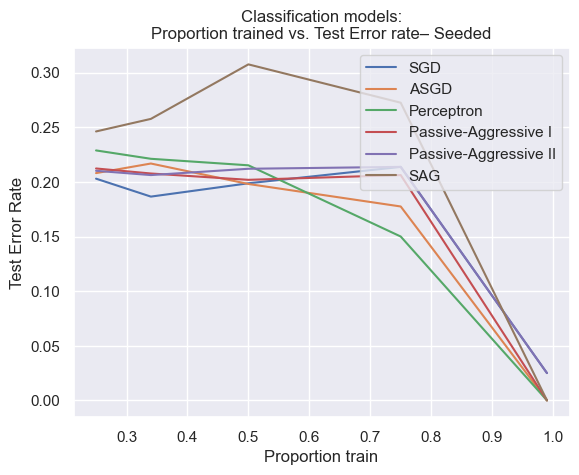

0.7341248989105225 seconds


In [31]:
start = time.time()
#heldout = [0.95, 0.90, 0.75, 0.50, 0.01] #works well for balanced dataset
heldout = [0.75, 0.66, 0.50, 0.25, 0.01]
rounds = 20

classifiers = [
    ("SGD", SGDClassifier(max_iter=100)),
    ("ASGD", SGDClassifier(average=True)),
    ("Perceptron", Perceptron()),
    ("Passive-Aggressive I", PassiveAggressiveClassifier(loss='hinge',
                                                         C=1.0, tol=1e-4)),
    ("Passive-Aggressive II", PassiveAggressiveClassifier(loss='squared_hinge',
                                                          C=1.0, tol=1e-4)),
    ("SAG", LogisticRegression(solver='sag', tol=1e-1, C=1.e4 / X.shape[0]))
]

xx = 1. - np.array(heldout)

for name, clf in classifiers:
    print("training %s" % name)
    #rng = np.random.RandomState(42)
    rng = 42
    yy = []
    for i in heldout:
        yy_ = []
        for r in range(rounds):
            X_train, X_test, y_train, y_test = \
                train_test_split(X, y, test_size=i, random_state=rng)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            yy_.append(1 - np.mean(y_pred == np.array(y_test)))
        yy.append(np.mean(yy_))
    plt.plot(xx, yy, label=name)
plt.title('Classification models:\nProportion trained vs. Test Error rate– Seeded')
plt.legend(loc="upper right")
plt.xlabel("Proportion train")
plt.ylabel("Test Error Rate")
plt.savefig("Full_data_TestErrorRate_seed42")
plt.show()
end = time.time()
print(end-start, 'seconds')

## Consider Cross Validation now

In [32]:
#kf.split?

In [33]:
#KFold?

TRAIN: [  0   1   2   3   4   5   6   7   8  10  11  13  14  16  17  20  21  22
  23  25  26  27  28  32  33  34  35  36  37  38  39  40  41  42  43  44
  46  47  48  49  50  52  53  54  55  57  58  59  60  61  62  63  64  66
  67  68  70  71  72  73  74  76  77  78  79  80  82  83  84  85  86  87
  88  89  90  91  92  93  96  99 100 101 102 103 104 105 106 107 109 110
 112 113 114 115 116 117 118 120 121 122 123 124 127 129 130 131 132 134
 135 136 137 140 141 142 143 144 146 147 148 149 151 152 153 154 156] TEST: [  9  12  15  18  19  24  29  30  31  45  51  56  65  69  75  81  94  95
  97  98 108 111 119 125 126 128 133 138 139 145 150 155]
training SGD
training ASGD
training Perceptron
training Passive-Aggressive I
training Passive-Aggressive II
training SAG


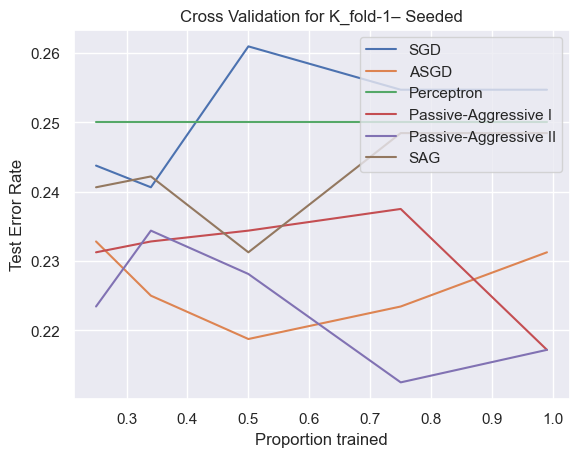

TRAIN: [  0   1   2   3   5   6   7   8   9  10  12  13  14  15  17  18  19  20
  21  23  24  25  28  29  30  31  33  34  35  37  38  39  40  43  44  45
  46  47  48  49  50  51  52  53  54  56  57  58  59  61  62  63  64  65
  69  70  71  72  73  74  75  77  80  81  82  83  85  87  88  89  90  91
  92  93  94  95  96  97  98  99 100 102 103 104 106 107 108 109 110 111
 112 113 114 115 116 117 119 120 121 123 125 126 128 129 130 131 133 134
 137 138 139 141 142 143 144 145 146 147 150 151 152 153 154 155 156] TEST: [  4  11  16  22  26  27  32  36  41  42  55  60  66  67  68  76  78  79
  84  86 101 105 118 122 124 127 132 135 136 140 148 149]
training SGD
training ASGD
training Perceptron
training Passive-Aggressive I
training Passive-Aggressive II
training SAG


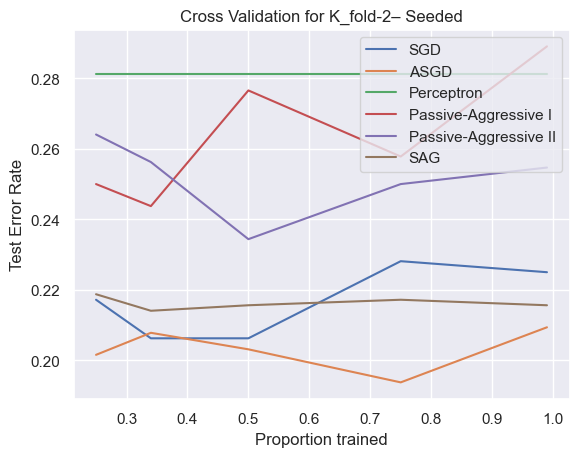

TRAIN: [  1   2   3   4   6   7   8   9  11  12  13  14  15  16  17  18  19  20
  21  22  24  26  27  29  30  31  32  34  35  36  37  38  41  42  43  45
  46  48  49  50  51  52  54  55  56  57  58  59  60  63  65  66  67  68
  69  70  71  72  74  75  76  77  78  79  80  81  83  84  86  87  88  89
  91  92  94  95  97  98  99 100 101 102 103 105 106 107 108 109 111 114
 115 116 118 119 120 121 122 124 125 126 127 128 129 130 132 133 134 135
 136 137 138 139 140 141 142 143 145 146 147 148 149 150 151 154 155 156] TEST: [  0   5  10  23  25  28  33  39  40  44  47  53  61  62  64  73  82  85
  90  93  96 104 110 112 113 117 123 131 144 152 153]
training SGD
training ASGD
training Perceptron
training Passive-Aggressive I
training Passive-Aggressive II
training SAG


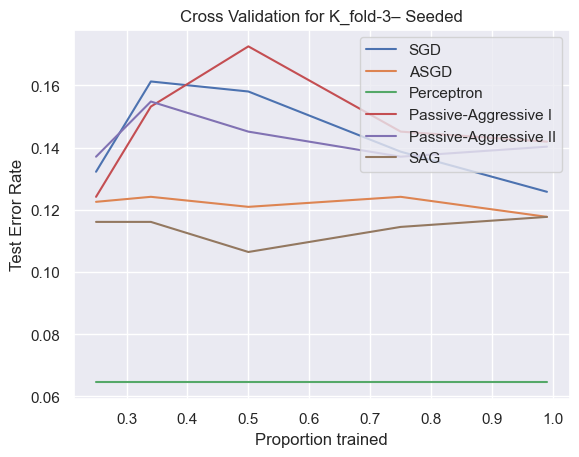

TRAIN: [  0   1   4   5   9  10  11  12  14  15  16  18  19  20  21  22  23  24
  25  26  27  28  29  30  31  32  33  36  37  39  40  41  42  44  45  47
  48  50  51  52  53  54  55  56  57  58  60  61  62  63  64  65  66  67
  68  69  71  73  74  75  76  78  79  81  82  84  85  86  87  88  90  92
  93  94  95  96  97  98  99 101 102 103 104 105 106 107 108 110 111 112
 113 115 116 117 118 119 121 122 123 124 125 126 127 128 129 130 131 132
 133 135 136 138 139 140 144 145 147 148 149 150 151 152 153 154 155 156] TEST: [  2   3   6   7   8  13  17  34  35  38  43  46  49  59  70  72  77  80
  83  89  91 100 109 114 120 134 137 141 142 143 146]
training SGD
training ASGD
training Perceptron
training Passive-Aggressive I
training Passive-Aggressive II
training SAG


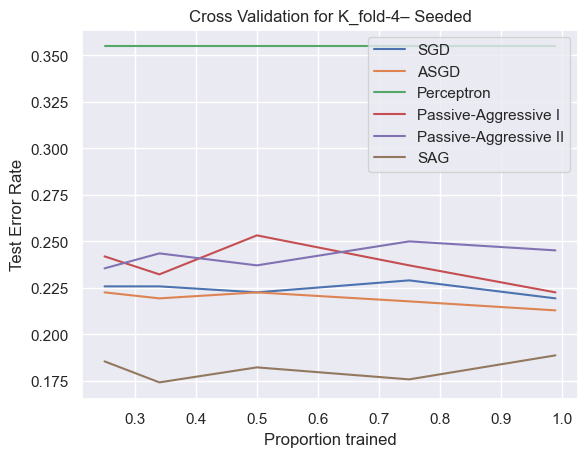

TRAIN: [  0   2   3   4   5   6   7   8   9  10  11  12  13  15  16  17  18  19
  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  38  39  40
  41  42  43  44  45  46  47  49  51  53  55  56  59  60  61  62  64  65
  66  67  68  69  70  72  73  75  76  77  78  79  80  81  82  83  84  85
  86  89  90  91  93  94  95  96  97  98 100 101 104 105 108 109 110 111
 112 113 114 117 118 119 120 122 123 124 125 126 127 128 131 132 133 134
 135 136 137 138 139 140 141 142 143 144 145 146 148 149 150 152 153 155] TEST: [  1  14  20  21  37  48  50  52  54  57  58  63  71  74  87  88  92  99
 102 103 106 107 115 116 121 129 130 147 151 154 156]
training SGD
training ASGD
training Perceptron
training Passive-Aggressive I
training Passive-Aggressive II
training SAG


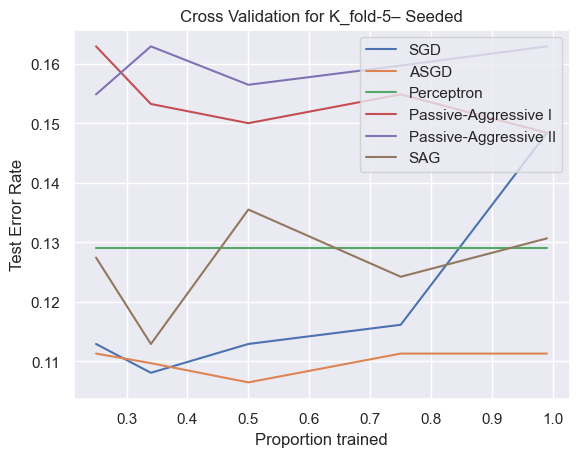

Time to run: -2.553075075149536 seconds


In [34]:
start = time.time()

rng = 42

#kf = KFold(n_splits=5)
kf = KFold(n_splits=5, random_state=rng, shuffle=True)
kf.get_n_splits(X)
#print(kf)

kFolds = ['K_fold-1','K_fold-2','K_fold-3','K_fold-4','K_fold-5']
rounds = 20
count = 0


for train_index, test_index in kf.split(X):
     print("TRAIN:", train_index, "TEST:", test_index)
     X_train, X_test = np.array(X)[np.array(train_index)], np.array(X)[np.array(test_index)]
     y_train, y_test = np.array(y)[np.array(train_index)], np.array(y)[np.array(test_index)]
        
     classifiers = [
        ("SGD", SGDClassifier(max_iter=100)),
        ("ASGD", SGDClassifier(average=True)),
        ("Perceptron", Perceptron()),
        ("Passive-Aggressive I", PassiveAggressiveClassifier(loss='hinge',
                                                             C=1.0, tol=1e-4)),
        ("Passive-Aggressive II", PassiveAggressiveClassifier(loss='squared_hinge',
                                                              C=1.0, tol=1e-4)),
        ("SAG", LogisticRegression(solver='sag', tol=1e-1, C=1.e4 / X.shape[0]))
     ]
     #count+=1

     for name, clf in classifiers:
         print("training %s" % name)
         yy = []
         for i in heldout:
             yy_ = []
             for r in range(rounds):
                 clf.fit(X_train, y_train)
                 y_pred = clf.predict(X_test)
                 yy_.append(1 - np.mean(y_pred == np.array(y_test)))
             yy.append(np.mean(yy_))
             #plt.title(f"Cross Validation Test Error Rate: {i}% trained")
         plt.plot(xx, yy, label=name)
         #plt.plot(heldout, yy, label=name)
     plt.title(f"Cross Validation for {kFolds[count]}– Seeded")
     plt.legend(loc="upper right")
     plt.xlabel("Proportion trained")#
     #plt.xlabel("Train-Test Index")
     plt.ylabel("Test Error Rate")
     plt.savefig(f"{kFolds[count]}CrossValidationSeeded.png")
     plt.show()
     #plt.savefig(f"CrossValidationTestErrorRate_{i}_percent_trained.png")
     
     count+=1
end = time.time()
print(f"Time to run: {start-end} seconds")

https://github.com/adomakor412/capstone_AMS-pCal_MachineLearning/blob/master/ML_GOES_16_validation.ipynb

In [35]:
df_ml = dfexp[dfexp.columns[:-1]]

In [36]:
['97']

['97']

In [37]:
df_ml['124']

4      134.08
5      206.62
6      197.53
7      211.92
8      207.26
        ...  
156    291.28
157    299.09
158    493.81
159    498.65
160    425.14
Name: 124, Length: 157, dtype: float64

In [38]:
df_ml_feature = dfexp[dfexp['Target']==0]
df_ml_feature

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000,0
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000,0
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000,0
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000,0
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000,0
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867,0
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,26.8,28.4,98.76,291.68,390.44,493.81,0.791,390.44,1683.000,0
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,27.4,29.0,99.73,218.76,318.49,498.65,0.639,318.49,1794.000,0


In [39]:
#df_ml_feature.drop?

In [40]:
df_ml_Target = df_ml_feature['97']/2
df_ml_feature = df_ml_feature.drop(columns=['Target','124','97'])

In [41]:
df_ml_feature

,1,2,3,4,5,6,7,8,15,16,...,117,118,119,120,121,122,123,125,126,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,35.7,41.5,37.5,39.1,26.82,41.06,67.88,0.506,67.88,1286.000
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.4,100.2,96.2,97.8,41.32,41.06,82.39,0.399,82.39,1245.000
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,83.4,91.8,87.8,89.4,39.51,53.38,92.89,0.470,92.89,1168.000
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.2,105.3,101.3,102.9,42.38,64.05,106.44,0.502,106.44,1154.000
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.9,100.8,96.8,98.4,41.45,41.06,82.51,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,41.7,47.9,43.9,45.5,58.26,49.37,107.63,0.369,107.63,1585.000
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,44.1,50.4,46.4,48.0,59.82,159.73,219.55,0.734,219.55,0.867
158,31.0,820.0,16.0,25.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,25.5,30.8,26.8,28.4,98.76,291.68,390.44,0.791,390.44,1683.000
159,32.0,821.0,16.0,27.0,1.0,655.0,155.0,820.0,207100.0,282.6,...,26.0,31.4,27.4,29.0,99.73,218.76,318.49,0.639,318.49,1794.000


In [42]:
df_ml_Target

4       47.305
5       68.850
6       68.345
7       69.085
8       51.310
        ...   
156    111.330
157    112.835
158    262.290
159    262.555
160    180.265
Name: 97, Length: 137, dtype: float64

In [43]:
X_train, X_test, y_train, y_test = train_test_split(df_ml_feature, df_ml_Target,random_state=rng,test_size=0.25)
regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

In [44]:
MAE_ML = []
MSE_ML = []
R2_ML = []
R2_ML_train_test = []

In [45]:
regr.score?

Signature: regr.score(X, y, sample_weight=None)
Docstring:
Return the coefficient of determination of the prediction.

The coefficient of determination :math:`R^2` is defined as
:math:`(1 - \frac{u}{v})`, where :math:`u` is the residual
sum of squares ``((y_true - y_pred)** 2).sum()`` and :math:`v`
is the total sum of squares ``((y_true - y_true.mean()) ** 2).sum()``.
The best possible score is 1.0 and it can be negative (because the
model can be arbitrarily worse). A constant model that always predicts
the expected value of `y`, disregarding the input features, would get
a :math:`R^2` score of 0.0.

Parameters
----------
X : array-like of shape (n_samples, n_features)
    Test samples. For some estimators this may be a precomputed
    kernel matrix or a list of generic objects instead with shape
    ``(n_samples, n_samples_fitted)``, where ``n_samples_fitted``
    is the number of samples used in the fitting for the estimator.

y : array-like of shape (n_samples,) or (n_samples, n_out

In [46]:
train = regr.score(X_train,y_train)
test = regr.score(X_test, y_test)

R2_ML.append(test)
R2_ML_train_test.append(train/test)

prediction = regr.predict(X_test)
errors = abs(prediction - y_test)

MAE = round(np.mean(errors), 2)
MAE_ML.append(MAE)

MSE = mean_squared_error(prediction, y_test)
MSE_ML.append(MSE)

print(MAE_ML) 
print(MSE_ML)
print(R2_ML)
print(R2_ML_train_test)

[2669.5]
[8826097.832581285]
[-552.0188254386031]
[0.5079721112274765]


In [47]:
y_test

120     63.310
119    119.275
18      75.760
32     270.125
144     69.015
74     106.360
72      98.840
130    135.315
157    112.835
95     146.425
94     149.095
53     194.590
77     116.885
75      77.135
39     158.820
50     198.810
33     270.125
25     124.605
156    111.330
64     166.255
146    394.300
8       51.310
124    124.860
44     161.000
99     545.500
115     68.535
22      69.800
24     203.265
14     120.725
154    390.425
59     166.255
17     144.580
129    138.775
84     599.785
113     90.680
Name: 97, dtype: float64

In [48]:
prediction

array([2039.6784332 , 2101.97446409, 1982.91096768, 4090.46166052,
       1724.47750321, 2919.64109294, 2881.29706647, 2064.60274199,
       1588.0516274 , 3068.29160647, 3017.58646704, 2220.38531255,
       2950.68293339, 2888.29554143, 2192.29608383, 2332.10315888,
       4030.00997895, 2473.71494534, 1745.26400287, 2345.28282048,
       3856.64265107, 1003.94908174, 2083.67226772, 2177.46080861,
       6324.57314702, 1578.39961421, 2320.86807752, 2604.03566976,
       3284.40109749, 6246.31345736, 2315.75883079, 3634.49165143,
       2029.10894771, 7802.86716116, 1547.55898075])

# Scaled regression

In [49]:
MAE_ML_scaled = []
MSE_ML_scaled  = []
R2_ML_scaled  = []
R2_ML_train_test_scaled = []

scalerScale_ML = []
scalerVar_ML = []                    
scalerMean_ML = [] 

X_trainScaled = X_train
#Y_trainScaled = y_train

scalerTrainX = StandardScaler()
#scalerTrainY = StandardScaler()

scalerTrainX.fit(X_trainScaled)
#scalerTrainY.fit(Y_trainScaled)

X_testScaled = scalerTrainX.transform(X_test)
#Y_testScaled = scalerTrainY.transform(y_test)

regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)

train = regr.score(X_trainScaled,y_train)
test = regr.score(X_testScaled, y_test)

R2_ML_scaled.append(test)
R2_ML_train_test_scaled.append(train/test)

prediction = regr.predict(X_testScaled)
errors = abs(prediction - y_test)

MAE = round(np.mean(errors), 2)
MAE_ML_scaled.append(MAE)

MSE_scaled = mean_squared_error(prediction, y_test)
MSE_ML_scaled.append(MSE)

print(MAE_ML_scaled) 
print(MSE_ML_scaled)
print(R2_ML_scaled)
print(R2_ML_train_test_scaled)

# scalerScale_ML.append(scalerTrainY.scale_)
# scalerVar_ML.append(scalerTrainY.var_)                 
# scalerMean_ML.append(scalerTrainY.mean_)

print(scalerScale_ML)
print(scalerVar_ML)                 
print(scalerMean_ML)


[172.19]
[8826097.832581285]
[-1.8533014573479791]
[151.3030527675826]
[]
[]
[]


In [50]:
y_test

120     63.310
119    119.275
18      75.760
32     270.125
144     69.015
74     106.360
72      98.840
130    135.315
157    112.835
95     146.425
94     149.095
53     194.590
77     116.885
75      77.135
39     158.820
50     198.810
33     270.125
25     124.605
156    111.330
64     166.255
146    394.300
8       51.310
124    124.860
44     161.000
99     545.500
115     68.535
22      69.800
24     203.265
14     120.725
154    390.425
59     166.255
17     144.580
129    138.775
84     599.785
113     90.680
Name: 97, dtype: float64

In [51]:
prediction, 

(array([ 0.46082988,  0.40295605, -0.47027255, -0.93092506,  0.45500383,
         0.55467703,  0.33550638,  4.44943363, -0.27156506,  0.71792533,
         0.38282803, -0.41846103,  0.58509499,  0.52821065, -0.34815405,
        -0.05069251, -0.56818724, -0.0663351 , -0.09294132, -0.39362922,
         0.18242649, -0.44224503,  0.41907213, -0.07870622,  1.10377458,
        -0.45874355,  0.03773135, -0.43289306, -0.56922431,  0.41607659,
        -0.09272268, -0.68927627,  0.97856677,  2.67624092, -0.20137224]),)

In [52]:
regr.predict(X_trainScaled)

array([ 8203.68070408,  1676.54314872,   952.58166486,  3064.66180876,
        2209.46266668,  2207.16172335,  2688.52916901,  2205.43867474,
        1127.17428772,  1657.5672534 ,  2444.84076903,  1309.95241928,
        6162.15207823,  2035.74885411,  2044.62917711,  2356.76657305,
        1642.98448797,  1538.58704404,  2120.6016376 ,  2232.42171773,
        3113.40494797,  2077.4647445 ,  1856.5998301 ,  2222.50639281,
        4405.28319591,  2703.08554043,  3067.0615233 ,  2147.87741408,
        2936.20130747,  2888.06971594,  2346.07528486,  5574.31948802,
        3081.99715665,  3088.14811758,  2197.54949409,  2203.01499905,
        2178.5069064 ,  1679.29347133,  6268.03586042,  2318.68063633,
        2887.55034951,  3063.85156797,  2018.01204815,  1628.3006706 ,
       16512.41922806,  1977.20410808,  1707.8707084 ,  1021.95727572,
        2630.74930171,  2068.95104928,  2925.91095493,  2682.99991837,
        5712.37559709,  4509.68102292,  1392.11825537,  2639.65502703,
      

In [53]:
y_train

136    483.110
116    126.965
4       47.305
86     150.055
70     161.430
        ...   
79     114.205
121     83.760
20      45.050
107     72.100
117     84.860
Name: 97, Length: 102, dtype: float64

In [54]:
X_trainScaled

,1,2,3,4,5,6,7,8,15,16,...,117,118,119,120,121,122,123,125,126,127
136,131.0,658.0,34.0,21.0,0.0,457.2,457.2,870.0,397741.0,435.0,...,65.0,72.4,68.4,70.0,484.17,245.58,729.75,0.301,729.75,1080.0
116,111.0,565.0,30.0,148.0,1.0,301.0,120.0,307.0,60732.0,151.9,...,37.1,43.0,39.0,40.6,35.30,102.29,137.59,0.779,137.59,1386.0
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,35.7,41.5,37.5,39.1,26.82,41.06,67.88,0.506,67.88,1286.0
86,84.0,492.0,21.0,136.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,12.9,17.6,13.6,15.2,38.79,221.94,260.73,1344.000,193.97,1661.0
70,68.0,400.0,17.0,110.0,1.0,250.0,250.0,350.0,87500.0,175.0,...,64.8,72.2,68.2,69.8,101.33,90.99,192.31,0.380,192.31,1476.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,77.0,434.0,18.0,5.0,0.0,254.0,254.0,508.0,129032.0,254.0,...,29.9,35.4,31.4,33.0,110.51,59.91,170.42,0.308,170.42,1365.0
121,116.0,615.0,31.0,119.0,1.0,610.0,152.0,305.0,81168.0,103.4,...,26.3,31.7,27.7,29.3,34.69,43.47,78.16,0.451,78.16,1766.0
20,15.0,137.0,6.0,22.0,1.0,139.0,139.0,260.0,36140.0,130.0,...,24.9,30.2,26.2,27.8,28.49,57.77,86.25,0.606,86.25,1109.0
107,154.0,534.0,45.0,126.0,1.0,400.0,110.0,355.0,62250.0,126.3,...,27.9,33.4,29.4,31.0,30.29,54.47,84.76,0.560,84.76,1620.0


# Attempt with all data and target scaled

In [55]:
df_ml_Target = df_standard['97']
df_ml_feature = df_standard.drop(columns = ['97', '124', '127'])

In [56]:
rng = 42
X_train, X_test, y_train, y_test = train_test_split(df_ml_feature, df_ml_Target,random_state=rng,test_size=0.25)
regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

In [57]:
MAE_ML_scaled = []
MSE_ML_scaled  = []
R2_ML_scaled  = []
R2_ML_train_test_scaled = []

scalerScale_ML = []
scalerVar_ML = []                    
scalerMean_ML = [] 

X_trainScaled = X_train
#Y_trainScaled = y_train

scalerTrainX = StandardScaler()
#scalerTrainY = StandardScaler()

scalerTrainX.fit(X_trainScaled)
#scalerTrainY.fit(Y_trainScaled)

X_testScaled = scalerTrainX.transform(X_test)
#Y_testScaled = scalerTrainY.transform(y_test)

regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)

train_scaled_score = regr.score(X_trainScaled,y_train)
test_scaled_score = regr.score(X_testScaled, y_test)

R2_ML_scaled.append(test_scaled_score)
R2_ML_train_test_scaled.append(train_scaled_score/test_scaled_score)

prediction = regr.predict(X_testScaled)
errors = abs(prediction - y_test)

MAE = round(np.mean(errors), 2)
MAE_ML_scaled.append(MAE)

MSE_scaled = mean_squared_error(prediction, y_test)
MSE_ML_scaled.append(MSE_scaled)

print(MAE_ML_scaled) 
print(MSE_ML_scaled)
print(R2_ML_scaled)
print(R2_ML_train_test_scaled)

# scalerScale_ML.append(scalerTrainY.scale_)
# scalerVar_ML.append(scalerTrainY.var_)                 
# scalerMean_ML.append(scalerTrainY.mean_)

# print(scalerScale_ML)
# print(scalerVar_ML)                 
# print(scalerMean_ML)

print(train_scaled_score)
print(test_scaled_score)

[0.36]
[0.4831063394708958]
[0.5502090521920249]
[1.8112047811017158]
0.996541265935639
0.5502090521920249


In [58]:
y_test

130   -0.352715
49    -0.216908
137    2.177668
142   -0.714425
115   -0.713318
33     0.375243
99     1.862235
101    2.901360
98     1.862235
143   -0.695742
23    -0.028560
60    -0.185642
19    -0.423831
73    -0.491302
28    -0.529696
34     0.492690
129   -0.334031
112   -0.650815
159    0.334366
69    -0.211697
123   -0.510877
22    -0.706488
16     0.188407
13    -0.742613
35    -0.225790
85    -0.183104
55    -0.504964
132    0.490449
149    2.550665
102    2.958275
154    1.024848
79    -0.466706
140   -0.383413
59    -0.185642
128   -0.364027
88    -0.275631
109   -0.694608
46    -0.530749
71    -0.526942
131   -0.352715
Name: 97, dtype: float64

In [59]:
prediction

array([ 2.86893273, -0.32221186,  1.93923399, -0.86836443, -0.78200153,
        0.35587723,  2.45260628,  3.25587441,  2.50730354, -0.73162929,
        0.05946188, -0.1827858 , -0.45591612, -0.49534229, -0.05913296,
        0.3952081 ,  0.50158776, -0.68593299,  0.60993834, -0.16898631,
       -0.55568235, -0.30374864,  0.93365797, -0.77030738,  0.02909452,
        0.40042209, -0.50600545,  0.46735888,  3.62970734,  3.07808428,
        0.80190475, -0.39261118, -0.3934958 , -0.20268618,  1.52478691,
       -0.1741865 , -0.68853514, -0.38450981, -0.72061219,  0.61806482])

https://github.com/adomakor412/Visualization/blob/master/PCA.ipynb

In [60]:
# data = pd.read_excel("preliminary_162x127.xlsx")
# data.head()

In [61]:
indicators = df_standard.columns[:-1]
#indicators = df_standard.drop(columns = ['97', 'Target']).columns
indicators

Index(['1', '2', '3', '4', '5', '6', '7', '8', '15', '16', '22', '23', '25',
       '26', '28', '29', '30', '32', '33', '34', '35', '44', '45', '46', '47',
       '48', '49', '55', '60', '61', '62', '65', '66', '67', '68', '69', '70',
       '71', '72', '75', '76', '79', '82', '83', '85', '86', '87', '88', '89',
       '90', '91', '92', '93', '94', '95', '96', '97', '98', '100', '101',
       '102', '103', '104', '105', '106', '107', '108', '110', '111', '112',
       '113', '114', '115', '117', '118', '119', '120', '121', '122', '123',
       '124', '125', '126', '127'],
      dtype='object')

In [62]:
df_standard

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
4,-1.721054,-2.149086,-1.968835,-0.354802,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,-0.332096,-0.332096,-0.725716,-0.498787,-0.681524,-0.725763,-0.407708,-0.824918,-0.560683,-0.38208
5,-1.698989,-2.134291,-1.968835,-0.444502,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.012806,2.012806,-0.566462,-0.498787,-0.629092,-0.566421,-0.407836,-0.743611,-0.644550,-0.38208
6,-1.676924,-2.129359,-1.968835,-0.422077,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,1.677249,1.677249,-0.586341,-0.448635,-0.591150,-0.586388,-0.407751,-0.684774,-0.802055,-0.38208
7,-1.654859,-2.124427,-1.968835,-0.399652,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.216537,2.216537,-0.554820,-0.405199,-0.542187,-0.554779,-0.407712,-0.608846,-0.830693,-0.38208
8,-1.632794,-2.119495,-1.968835,-0.377227,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.036774,2.036774,-0.565034,-0.498787,-0.628658,-0.565015,-0.407837,-0.742938,-0.859330,-0.38208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,1.235628,1.786460,1.191769,-1.677882,0.486025,-0.841859,0.100142,-0.772621,-0.703170,-0.585147,...,-0.076434,-0.076434,-0.380409,-0.464959,-0.537887,-0.380455,-0.407872,-0.602177,0.050929,-0.38208
157,1.257693,1.796324,1.191769,-1.655457,0.486025,-0.841859,0.100142,-0.772621,-0.703170,-0.585147,...,0.023434,0.023434,-0.363275,-0.015704,-0.133461,-0.363300,-0.407435,0.024972,-3.189455,-0.38208
158,-1.037045,1.801255,-0.523987,-1.139680,0.486025,0.791178,-0.446278,1.484465,0.780059,0.641907,...,-0.759532,-0.759532,0.064405,0.521440,0.484055,0.064425,-0.407366,0.982562,0.251390,-0.38208
159,-1.014980,1.806187,-0.523987,-1.094830,0.486025,0.791178,-0.446278,1.484465,0.780059,0.641907,...,-0.735563,-0.735563,0.075058,0.224596,0.224061,0.075057,-0.407548,0.579387,0.478444,-0.38208


In [63]:
#standardized_features

In [64]:
# x = df_standard.drop(columns=['97', 'Target'])
x = df_standard.drop(columns=['Target'])

In [65]:
pca = PCA(n_components=20)
principalComponents = pca.fit_transform(x)
loading =np.transpose(pca.components_)
chart = pd.DataFrame(loading,columns =['PC 1','PC 2','PC 3','PC 4','PC 5','PC 6','PC 7','PC 8', 'PC 9','PC 10',
                                       'PC 11','PC 12','PC 13','PC 14','PC 15','PC 16','PC 17','PC 18','PC 19','PC 20'],
                     index=indicators)
chart

,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,PC 7,PC 8,PC 9,PC 10,PC 11,PC 12,PC 13,PC 14,PC 15,PC 16,PC 17,PC 18,PC 19,PC 20
1,0.037231,0.041238,-0.075431,0.012919,0.311379,0.238188,-0.182632,-0.118134,0.161464,-0.084262,0.224781,-0.012140,-0.019004,-0.098649,-0.048120,0.124606,-0.034978,0.006923,0.029610,-0.013850
2,0.028844,0.035215,-0.074287,0.015866,0.275701,0.213207,-0.173148,-0.134778,0.237427,-0.149279,0.254534,-0.019927,0.079595,0.012661,-0.010277,0.016781,-0.103938,0.012805,0.100321,0.010503
3,0.052881,0.025407,-0.067073,-0.036973,0.241573,0.262188,-0.168919,-0.209541,0.147271,-0.130681,0.148088,-0.129881,-0.027047,0.013362,-0.052545,0.113208,-0.022179,-0.022214,-0.021277,-0.177154
4,-0.016478,0.088842,-0.154533,0.080174,0.034831,-0.019085,0.002504,-0.244900,-0.036744,-0.102025,-0.151197,0.372834,-0.129261,0.077583,-0.100654,-0.000180,0.291742,-0.075749,-0.053363,0.045894
5,0.029132,0.034211,-0.124395,0.059994,0.040658,-0.032983,0.166536,-0.098446,0.082221,-0.351440,0.131756,0.303757,0.008277,-0.054835,0.078840,0.164516,0.288355,-0.018143,0.269240,-0.030568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,0.172393,-0.083909,-0.057127,-0.097014,0.001259,0.006417,0.062298,-0.027046,0.071968,0.066844,-0.014969,-0.087184,0.058294,0.034356,-0.096765,0.073785,-0.027979,-0.030044,-0.080443,-0.106966
124,0.059364,-0.188031,0.086608,-0.000231,0.015516,0.136741,-0.030751,0.020969,0.199897,0.085553,-0.022512,0.037264,-0.149723,0.096239,-0.130549,-0.044400,0.047530,-0.049766,-0.149331,0.214770
125,0.116693,0.082260,-0.188447,-0.050556,-0.042904,-0.008780,-0.066073,0.203703,0.048519,0.043147,-0.093502,-0.037983,0.024417,0.135116,-0.214483,0.072998,0.039438,-0.032686,0.062160,-0.056070
126,0.157865,-0.133058,0.033783,-0.057642,0.029665,0.062730,0.051119,-0.035334,0.108700,0.073940,0.032377,0.048352,-0.007222,-0.017176,0.022797,-0.036948,-0.057413,0.022637,-0.062056,0.071603


In [66]:
principalComponents.shape

(157, 20)

In [67]:
PCA_col_20 = ['PC 1','PC 2','PC 3','PC 4','PC 5','PC 6','PC 7','PC 8', 'PC 9','PC 10',
            'PC 11','PC 12','PC 13','PC 14','PC 15','PC 16','PC 17','PC 18','PC 19','PC 20']
finalDF = pd.DataFrame(principalComponents, columns=PCA_col_20)

In [68]:
x

,1,2,3,4,5,6,7,8,15,16,...,118,119,120,121,122,123,124,125,126,127
4,-1.721054,-2.149086,-1.968835,-0.354802,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,-0.332096,-0.332096,-0.332096,-0.725716,-0.498787,-0.681524,-0.725763,-0.407708,-0.824918,-0.560683
5,-1.698989,-2.134291,-1.968835,-0.444502,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.012806,2.012806,2.012806,-0.566462,-0.498787,-0.629092,-0.566421,-0.407836,-0.743611,-0.644550
6,-1.676924,-2.129359,-1.968835,-0.422077,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,1.677249,1.677249,1.677249,-0.586341,-0.448635,-0.591150,-0.586388,-0.407751,-0.684774,-0.802055
7,-1.654859,-2.124427,-1.968835,-0.399652,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.216537,2.216537,2.216537,-0.554820,-0.405199,-0.542187,-0.554779,-0.407712,-0.608846,-0.830693
8,-1.632794,-2.119495,-1.968835,-0.377227,-2.057507,-1.103863,-0.786272,-0.972286,-0.982896,-0.797984,...,2.036774,2.036774,2.036774,-0.565034,-0.498787,-0.628658,-0.565015,-0.407837,-0.742938,-0.859330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,1.235628,1.786460,1.191769,-1.677882,0.486025,-0.841859,0.100142,-0.772621,-0.703170,-0.585147,...,-0.076434,-0.076434,-0.076434,-0.380409,-0.464959,-0.537887,-0.380455,-0.407872,-0.602177,0.050929
157,1.257693,1.796324,1.191769,-1.655457,0.486025,-0.841859,0.100142,-0.772621,-0.703170,-0.585147,...,0.023434,0.023434,0.023434,-0.363275,-0.015704,-0.133461,-0.363300,-0.407435,0.024972,-3.189455
158,-1.037045,1.801255,-0.523987,-1.139680,0.486025,0.791178,-0.446278,1.484465,0.780059,0.641907,...,-0.759532,-0.759532,-0.759532,0.064405,0.521440,0.484055,0.064425,-0.407366,0.982562,0.251390
159,-1.014980,1.806187,-0.523987,-1.094830,0.486025,0.791178,-0.446278,1.484465,0.780059,0.641907,...,-0.735563,-0.735563,-0.735563,0.075058,0.224596,0.224061,0.075057,-0.407548,0.579387,0.478444


In [69]:
# Z=finalDf[['principal component 1','principal component 2']]
# X=finalDf[['principal component 1']]
# Y=finalDf[['principal component 2']]
# Z=chart[['PC 1','PC 2']]
# X=chart[['PC 1']]
# Y=chart[['PC 2']]
Z=finalDF[['PC 1','PC 2']]
X=finalDF[['PC 1']]
Y=finalDF[['PC 2']]


In [70]:
#KMeans?

In [71]:
#df_standard['Target'] == target

In [72]:
#chart.loc[indicesToKeep, 'PC 1']

In [73]:
#chart.size
#chart#.loc[df_standard['Target'] == target]

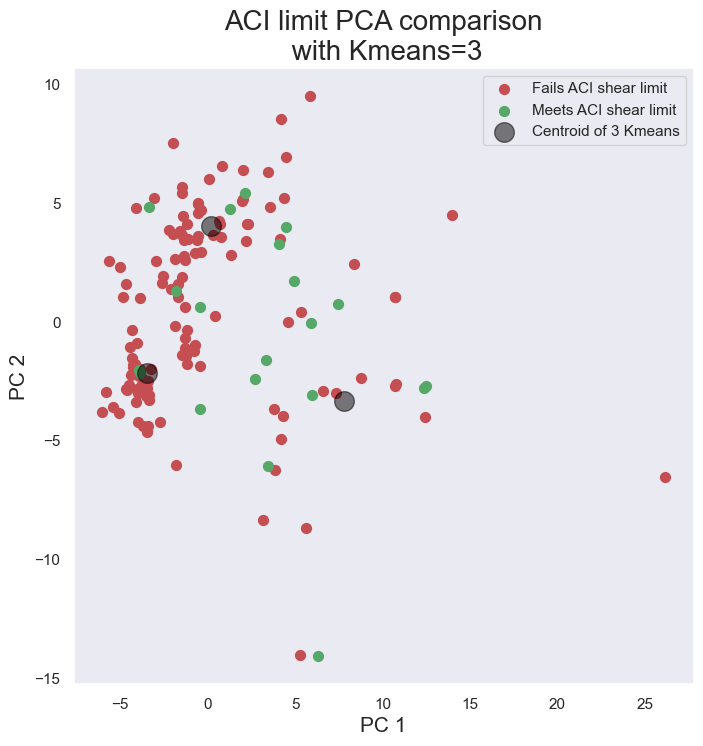

In [74]:
# Z=principalDf[['principal component 1','principal component 2']]
# connectivity_centroid=KMeans(n_clusters=6)
# connectivity_centroid.fit(Z)
# y_kmeans = connectivity_centroid.predict(Z)
#Z=chart[['PC 1','PC 2']]
connectivity_centroid=KMeans(n_clusters=3)
connectivity_centroid.fit(Z)
y_kmeans = connectivity_centroid.predict(Z)

# fig = plt.figure(figsize = (8,8))
# ax = fig.add_subplot(1,1,1) 
# ax.set_xlabel('Principal Component 1', fontsize = 15)
# ax.set_ylabel('Principal Component 2', fontsize = 15)
# ax.set_title('2 component PCA', fontsize = 20)
# salaries = [0, 500, 1000]
# colors = ['r', 'g', 'b']
# for salary, color in zip(salaries,colors):
#     indicesToKeep = finalDf['Salary'] >= salary
#     ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
#                , finalDf.loc[indicesToKeep, 'principal component 2']
#                , c = color
#                , s = 50)
# ax.legend(['<=$500k', '<=$100k', '>$0.1M'])
# ax.grid()

# #plt.scatter(X, Y, c='b', s=50, cmap='viridis')

# centers = connectivity_centroid.cluster_centers_
# ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

# plt.scatter(X, Y, c='b', s=50, cmap='viridis')

# centers = connectivity_centroid.cluster_centers_
# ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);
#plt.legend(['Centroid of fails ACI shear limit', 'Centroid of meets ACI shear limit'])

fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('PC 1', fontsize = 15)
ax.set_ylabel('PC 2', fontsize = 15)
ax.set_title('ACI limit PCA comparison\n with Kmeans=3', fontsize = 20)
targets = df_standard['Target'].unique()
colors = ['r', 'g']
for target, color in zip(targets,colors):
    indicesToKeep = df_standard['Target'] == target
    ax.scatter(finalDF.loc[finalDF.index[indicesToKeep], 'PC 1']
               , finalDF.loc[finalDF.index[indicesToKeep], 'PC 2']
               , c = color
               , s = 50)
#ax.legend(['Fails ACI shear limit', 'Meets ACI shear limit'])
ax.grid()

centers = connectivity_centroid.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);
#ax.scatter(centers[:, 0], centers[:, 1], c='purple', s=200, alpha=0.5);
#ax.legend(['Fails ACI shear limit', 'Meets ACI shear limit','Centroids'])
ax.legend(['Fails ACI shear limit', 'Meets ACI shear limit',
           'Centroid of 3 Kmeans'])

plt.savefig(f"ACI_limit_PCA_centroid_Comparison_3Kmeans.png")

# Kmeans 2 with All data comparison

In [75]:
Z=finalDF[['PC 1','PC 2']]
connectivity_centroid=KMeans(n_clusters=2)
connectivity_centroid.fit(Z)
y_kmeans = connectivity_centroid.predict(Z)

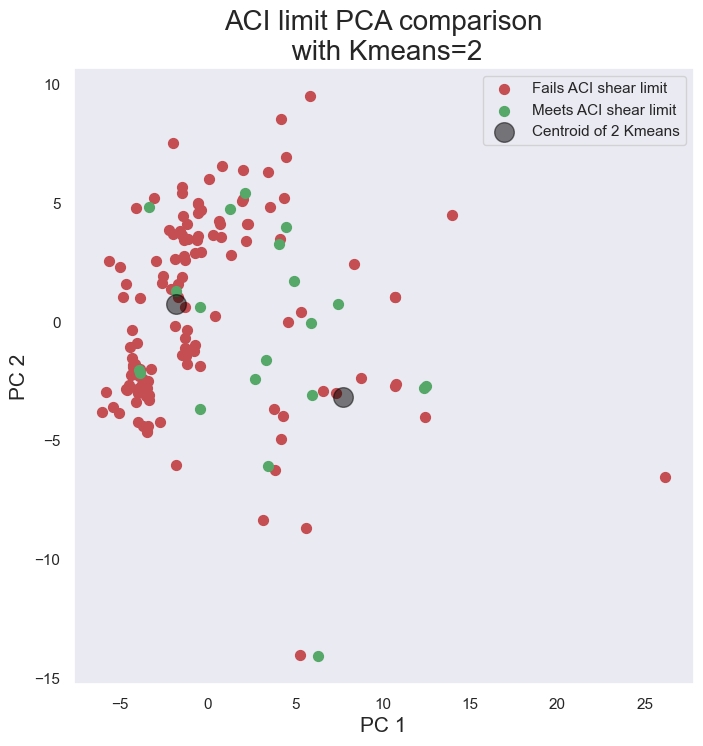

In [76]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('PC 1', fontsize = 15)
ax.set_ylabel('PC 2', fontsize = 15)
ax.set_title('ACI limit PCA comparison\n with Kmeans=2', fontsize = 20)
targets = df_standard['Target'].unique()
colors = ['r', 'g']
for target, color in zip(targets,colors):
    indicesToKeep = df_standard['Target'] == target
    ax.scatter(finalDF.loc[finalDF.index[indicesToKeep], 'PC 1']
               , finalDF.loc[finalDF.index[indicesToKeep], 'PC 2']
               , c = color
               , s = 50)
#ax.legend(['Fails ACI shear limit', 'Meets ACI shear limit'])
ax.grid()

centers = connectivity_centroid.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);
#ax.scatter(centers[:, 0], centers[:, 1], c='purple', s=200, alpha=0.5);
#ax.legend(['Fails ACI shear limit', 'Meets ACI shear limit','Centroids'])
ax.legend(['Fails ACI shear limit', 'Meets ACI shear limit',
           'Centroid of 2 Kmeans'])

plt.savefig(f"ACI_limit_PCA_centroid_Comparison_2Kmeans.png")

# Regress from Kmeans 2 with All data comparison

In [77]:
KMeans

sklearn.cluster._kmeans.KMeans

In [78]:
connectivity_centroid

KMeans(n_clusters=2)

In [79]:
y_kmeans

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0], dtype=int32)

In [80]:
y_kmeans.shape

(157,)

In [81]:
dfexp[dfexp['Target']==1]

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
15,11.0,64.0,4.0,29.0,1.0,240.0,240.0,950.0,228000.0,475.0,...,22.7,24.3,176.75,140.42,317.17,883.75,0.359,317.17,1165.0,1
16,12.0,65.0,4.0,30.0,1.0,240.0,240.0,1250.0,300000.0,625.0,...,21.8,23.4,231.28,187.23,418.51,1156.42,0.362,418.51,1129.0,1
34,30.0,264.0,15.0,18.0,0.0,304.8,304.8,609.6,185806.0,304.8,...,51.9,53.5,199.42,122.65,322.06,997.08,0.323,322.06,1206.0,1
35,33.0,359.0,17.0,75.0,1.0,250.0,250.0,350.0,87500.0,175.0,...,57.6,59.2,93.28,63.69,156.97,466.41,0.337,156.97,1454.0,1
87,85.0,493.0,21.0,137.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,13.0,14.6,38.13,139.42,177.55,190.64,0.931,177.55,1549.0,1
88,86.0,494.0,21.0,138.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,13.0,14.6,38.13,82.66,120.79,190.64,0.634,120.79,1924.0,1
100,98.0,508.0,22.0,69.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,46.0,47.6,129.26,680.39,809.65,646.29,1253.000,646.29,1827.0,1
101,99.0,509.0,22.0,70.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,46.0,47.6,129.26,680.39,809.65,646.29,1253.000,646.29,1917.0,1
104,102.0,512.0,24.0,20.0,1.0,700.0,120.0,600.0,159600.0,261.1,...,22.6,24.2,52.95,219.52,272.47,264.73,1029.000,264.73,1643.0,1
105,103.0,523.0,25.0,72.0,1.0,650.0,86.3,490.0,90550.0,168.0,...,36.1,37.7,39.60,57.65,97.25,198.02,0.491,97.25,1296.0,1


In [82]:
dfexp[dfexp['Target']==y_kmeans]

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,37.5,39.1,26.82,41.06,67.88,134.08,0.506,67.88,1286.000,0
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.2,97.8,41.32,41.06,82.39,206.62,0.399,82.39,1245.000,0
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,87.8,89.4,39.51,53.38,92.89,197.53,0.470,92.89,1168.000,0
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,101.3,102.9,42.38,64.05,106.44,211.92,0.502,106.44,1154.000,0
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.8,98.4,41.45,41.06,82.51,207.26,0.398,82.51,1140.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,150.0,803.0,43.0,55.0,1.0,375.0,375.0,750.0,281250.0,375.0,...,32.0,33.6,236.48,122.86,359.33,1182.38,0.304,359.33,1344.000,1
153,151.0,806.0,43.0,53.0,1.0,375.0,375.0,750.0,281250.0,375.0,...,63.0,64.6,327.90,173.60,501.49,1639.48,0.306,501.49,1374.000,1
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,43.9,45.5,58.26,49.37,107.63,291.28,0.369,107.63,1585.000,0
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,46.4,48.0,59.82,159.73,219.55,299.09,0.734,219.55,0.867,0


In [83]:
df_regr_k2 = dfexp[dfexp['Target']!=y_kmeans]
df_regr_k2

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
9,5.0,40.0,2.0,35.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,28.0,29.6,250.76,111.61,362.37,1253.79,0.289,362.37,0.734,0
10,6.0,42.0,8.0,36.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,34.0,35.6,275.00,111.61,386.61,1375.00,0.281,386.61,0.723,0
11,7.0,45.0,3.0,147.0,1.0,585.0,75.0,800.0,277821.0,420.5,...,40.5,42.1,56.88,468.65,525.53,284.40,1848.000,284.40,3118.000,0
12,8.0,46.0,44.0,46.0,1.0,1450.0,150.0,1450.0,830000.0,550.1,...,39.3,40.9,218.12,2002.57,2220.69,1090.62,2036.000,1090.62,3103.000,0
34,30.0,264.0,15.0,18.0,0.0,304.8,304.8,609.6,185806.0,304.8,...,51.9,53.5,199.42,122.65,322.06,997.08,0.323,322.06,1206.000,1
35,33.0,359.0,17.0,75.0,1.0,250.0,250.0,350.0,87500.0,175.0,...,57.6,59.2,93.28,63.69,156.97,466.41,0.337,156.97,1454.000,1
84,80.0,490.0,20.0,117.0,1.0,1500.0,100.0,900.0,362500.0,291.7,...,20.2,21.8,64.01,1020.61,1084.63,320.07,3389.000,320.07,2500.000,0
87,85.0,493.0,21.0,137.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,13.0,14.6,38.13,139.42,177.55,190.64,0.931,177.55,1549.000,1
88,86.0,494.0,21.0,138.0,1.0,960.0,160.0,440.0,134400.0,134.3,...,13.0,14.6,38.13,82.66,120.79,190.64,0.634,120.79,1924.000,1
96,94.0,504.0,22.0,65.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,21.0,22.6,89.07,453.60,542.66,445.33,1219.000,445.33,1518.000,0


In [84]:
list_match_index = [x for x in dfexp[dfexp['Target']==1].index for y in df_regr_k2.index if x == y]
list_match_index


[34, 35, 87, 88, 104, 105, 106, 132, 139, 151]

In [85]:
len(list_match_index)

10

# Kmeans 2 of filtered data

In [86]:
#min_class = min(y_kmeans.uni)
count_set = {}
for val in y_kmeans:
    count_set[val] = count_set.get(val,0)+1
min_kv = (math.inf,math.inf)
for key in count_set.keys():
    if min_kv[-1] > count_set[key]:
        min_kv = (key, count_set[key])
min_kv

(1, 30)

In [87]:
min_class = min_kv[0]

In [88]:
dfexp[y_kmeans == min_class]

,1,2,3,4,5,6,7,8,15,16,...,119,120,121,122,123,124,125,126,127,Target
9,5.0,40.0,2.0,35.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,28.0,29.6,250.76,111.61,362.37,1253.79,0.289,362.37,0.734,0
10,6.0,42.0,8.0,36.0,1.0,300.0,300.0,1000.0,300000.0,500.0,...,34.0,35.6,275.00,111.61,386.61,1375.00,0.281,386.61,0.723,0
11,7.0,45.0,3.0,147.0,1.0,585.0,75.0,800.0,277821.0,420.5,...,40.5,42.1,56.88,468.65,525.53,284.40,1848.000,284.40,3118.000,0
12,8.0,46.0,44.0,46.0,1.0,1450.0,150.0,1450.0,830000.0,550.1,...,39.3,40.9,218.12,2002.57,2220.69,1090.62,2036.000,1090.62,3103.000,0
15,11.0,64.0,4.0,29.0,1.0,240.0,240.0,950.0,228000.0,475.0,...,22.7,24.3,176.75,140.42,317.17,883.75,0.359,317.17,1165.000,1
16,12.0,65.0,4.0,30.0,1.0,240.0,240.0,1250.0,300000.0,625.0,...,21.8,23.4,231.28,187.23,418.51,1156.42,0.362,418.51,1129.000,1
84,80.0,490.0,20.0,117.0,1.0,1500.0,100.0,900.0,362500.0,291.7,...,20.2,21.8,64.01,1020.61,1084.63,320.07,3389.000,320.07,2500.000,0
96,94.0,504.0,22.0,65.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,21.0,22.6,89.07,453.60,542.66,445.33,1219.000,445.33,1518.000,0
97,95.0,505.0,22.0,66.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,21.0,22.6,89.07,453.60,542.66,445.33,1219.000,445.33,1545.000,0
98,96.0,506.0,22.0,67.0,1.0,900.0,120.0,1050.0,278000.0,432.8,...,43.0,44.6,125.12,453.60,578.71,625.59,0.925,578.71,1711.000,0


In [89]:
dfexp_sub = dfexp[y_kmeans == 0]
# dfexp_sub = dfexp_sub[dfexp_sub.columns[:-1]]
# df_ml_Target = dfexp_sub[dfexp_sub.columns[-1]]

df_ml_Target = dfexp_sub['97']/2
df_ml_feature = dfexp_sub.drop(columns=['Target','124','97'])

In [90]:
df_ml_feature

,1,2,3,4,5,6,7,8,15,16,...,117,118,119,120,121,122,123,125,126,127
4,0.0,19.0,0.0,60.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,35.7,41.5,37.5,39.1,26.82,41.06,67.88,0.506,67.88,1286.000
5,1.0,22.0,0.0,56.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.4,100.2,96.2,97.8,41.32,41.06,82.39,0.399,82.39,1245.000
6,2.0,23.0,0.0,57.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,83.4,91.8,87.8,89.4,39.51,53.38,92.89,0.470,92.89,1168.000
7,3.0,24.0,0.0,58.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,96.2,105.3,101.3,102.9,42.38,64.05,106.44,0.502,106.44,1154.000
8,4.0,25.0,0.0,59.0,0.0,127.0,127.0,254.0,32258.0,127.0,...,91.9,100.8,96.8,98.4,41.45,41.06,82.51,0.398,82.51,1140.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,148.0,783.0,42.0,111.0,0.0,304.8,114.3,304.8,49355.0,118.8,...,14.5,19.3,15.3,16.9,20.05,52.42,72.47,0.723,72.47,1456.000
151,149.0,786.0,42.0,48.0,0.0,304.8,114.3,304.8,49355.0,118.8,...,14.7,19.5,15.5,17.1,20.19,41.99,62.19,0.616,62.19,1399.000
156,134.0,817.0,35.0,1.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,41.7,47.9,43.9,45.5,58.26,49.37,107.63,0.369,107.63,1585.000
157,135.0,819.0,35.0,2.0,1.0,200.0,200.0,300.0,60000.0,150.0,...,44.1,50.4,46.4,48.0,59.82,159.73,219.55,0.734,219.55,0.867


In [91]:
df_ml_Target 

4       47.305
5       68.850
6       68.345
7       69.085
8       51.310
        ...   
150     51.335
151     41.160
156    111.330
157    112.835
160    180.265
Name: 97, Length: 127, dtype: float64

In [92]:
rng = 42
X_train, X_test, y_train, y_test = train_test_split(df_ml_feature, df_ml_Target,random_state=rng,test_size=0.25)
regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

In [93]:
MAE_ML_scaled = []
MSE_ML_scaled  = []
R2_ML_scaled  = []
R2_ML_train_test_scaled = []

scalerScale_ML = []
scalerVar_ML = []                    
scalerMean_ML = [] 

X_trainScaled = X_train
#Y_trainScaled = y_train

scalerTrainX = StandardScaler()
#scalerTrainY = StandardScaler()

scalerTrainX.fit(X_trainScaled)
#scalerTrainY.fit(Y_trainScaled)

X_testScaled = scalerTrainX.transform(X_test)
#Y_testScaled = scalerTrainY.transform(y_test)

regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)

train_scaled_score = regr.score(X_trainScaled,y_train)
test_scaled_score = regr.score(X_testScaled, y_test)

R2_ML_scaled.append(test_scaled_score)
R2_ML_train_test_scaled.append(train_scaled_score/test_scaled_score)

prediction = regr.predict(X_testScaled)
errors = abs(prediction - y_test)

MAE = round(np.mean(errors), 2)
MAE_ML_scaled.append(MAE)

MSE_scaled = mean_squared_error(prediction, y_test)
MSE_ML_scaled.append(MSE_scaled)

print(MAE_ML_scaled) 
print(MSE_ML_scaled)
print(R2_ML_scaled)
print(R2_ML_train_test_scaled)

# scalerScale_ML.append(scalerTrainY.scale_)
# scalerVar_ML.append(scalerTrainY.var_)                 
# scalerMean_ML.append(scalerTrainY.mean_)

# print(scalerScale_ML)
# print(scalerVar_ML)                 
# print(scalerMean_ML)

print(train_scaled_score)
print(test_scaled_score)

[128.27]
[20312.07664626633]
[-4.182905694975848]
[309.9162970093594]
-1296.350643726276
-4.182905694975848


In [94]:
y_test

36     158.820
129    138.775
92     153.365
65     161.430
54     163.465
114     90.680
91     153.365
157    112.835
132    291.460
72      98.840
55     107.120
8       51.310
28     102.540
113     90.680
46     102.345
112     80.110
29     196.925
144     69.015
20      45.050
50     198.810
21      57.345
116    126.965
122    132.740
88     149.590
4       47.305
89     155.105
78      71.855
79     114.205
22      69.800
52     324.490
41     161.000
37     158.820
Name: 97, dtype: float64

In [95]:
prediction

array([-3.99508914e-01,  1.15792378e+00,  2.44235335e+01,  1.37545888e-01,
       -6.03769492e-02, -4.00121818e-02,  2.03361483e+00, -3.94065733e-01,
        2.80062557e+00,  7.25191364e-01,  7.65764942e-02, -4.41715637e-01,
        3.95533335e-01, -2.91265447e-01, -9.41657295e-02, -1.78347821e-01,
        1.51988801e-01,  4.01748073e-01, -1.62892410e-01,  1.37966036e-01,
       -4.05444041e-01,  5.23248327e-03, -3.79766324e-01,  4.13584738e-01,
       -3.97270894e-01,  1.11036150e+00,  8.97494894e-01, -1.99284100e-01,
       -3.13084659e-01,  2.94329533e-01,  5.47172637e-02,  8.85375496e-03])

# Kmeans 2 of filtered data- all SCALED

In [106]:
min_class

1

In [101]:
dfexp_sub = df_standard[y_kmeans == min_class]

df_ml_Target = dfexp_sub['97']/2
df_ml_feature = dfexp_sub.drop(columns=['Target','124','97'])

In [102]:
df_ml_Target

9     -0.199266
10     0.115803
11     0.771902
12     3.416452
15    -0.058613
16     0.094204
84     1.077683
96     0.781082
97     0.781082
98     0.931117
99     0.931117
100    1.450680
101    1.450680
102    1.479137
133    0.444021
134    0.387377
135    0.513234
136    0.762668
137    1.088834
138    1.269798
146    0.522886
147    0.878738
148    1.214300
149    1.275333
152    0.406236
153    0.492242
154    0.512424
155    0.512424
158    0.166468
159    0.167183
Name: 97, dtype: float64

In [107]:
df_ml_Target = df_ml_Target[df_ml_Target>0]

In [109]:
df_ml_Target

10     0.115803
11     0.771902
12     3.416452
16     0.094204
84     1.077683
96     0.781082
97     0.781082
98     0.931117
99     0.931117
100    1.450680
101    1.450680
102    1.479137
133    0.444021
134    0.387377
135    0.513234
136    0.762668
137    1.088834
138    1.269798
146    0.522886
147    0.878738
148    1.214300
149    1.275333
152    0.406236
153    0.492242
154    0.512424
155    0.512424
158    0.166468
159    0.167183
Name: 97, dtype: float64

In [126]:
df_ml_feature.index
# df_ml_feature[df_ml_feature.index,:]
df_ml_feature = df_ml_feature.loc[df_ml_Target.index,:]

In [127]:
rng = 42
X_train, X_test, y_train, y_test = train_test_split(df_ml_feature, df_ml_Target,random_state=rng,test_size=0.25)
regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_train, y_train)

MAE_ML_scaled = []
MSE_ML_scaled  = []
R2_ML_scaled  = []
R2_ML_train_test_scaled = []

scalerScale_ML = []
scalerVar_ML = []                    
scalerMean_ML = [] 

X_trainScaled = X_train
#Y_trainScaled = y_train

scalerTrainX = StandardScaler()
#scalerTrainY = StandardScaler()

scalerTrainX.fit(X_trainScaled)
#scalerTrainY.fit(Y_trainScaled)

X_testScaled = scalerTrainX.transform(X_test)
#Y_testScaled = scalerTrainY.transform(y_test)

regr = MLPRegressor(random_state=rng, max_iter=500).fit(X_trainScaled, y_train)

train_scaled_score = regr.score(X_trainScaled,y_train)
test_scaled_score = regr.score(X_testScaled, y_test)

R2_ML_scaled.append(test_scaled_score)
R2_ML_train_test_scaled.append(train_scaled_score/test_scaled_score)

prediction = regr.predict(X_testScaled)
errors = abs(prediction - y_test)

MAE = round(np.mean(errors), 2)
MAE_ML_scaled.append(MAE)

MSE_scaled = mean_squared_error(prediction, y_test)
MSE_ML_scaled.append(MSE_scaled)

print(MAE_ML_scaled) 
print(MSE_ML_scaled)
print(R2_ML_scaled)
print(R2_ML_train_test_scaled)

# scalerScale_ML.append(scalerTrainY.scale_)
# scalerVar_ML.append(scalerTrainY.var_)                 
# scalerMean_ML.append(scalerTrainY.mean_)

# print(scalerScale_ML)
# print(scalerVar_ML)                 
# print(scalerMean_ML)

print(train_scaled_score)
print(test_scaled_score)

[1.1]
[1.5734176225416292]
[-6.14257521357875]
[-0.16267378895427922]
0.9992359839294962
-6.14257521357875


In [104]:
prediction

array([-3.63803657e-01, -1.57320141e-01,  7.79407508e-01,  3.29599856e-01,
       -6.38918529e-02,  2.58478242e-01, -5.23952252e+02,  1.53287126e-01])

In [105]:
y_test

155    0.512424
134    0.387377
149    1.275333
136    0.762668
97     0.781082
98     0.931117
158    0.166468
152    0.406236
Name: 97, dtype: float64

# Filter on data that pass ACI
## then check results against whether new prediction would pass test of others original data 